# The EM Algorithm for Gaussian Mixtures
**Course:** Machine Learning (20.IDI12) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

The notebook fits a two-component Gaussian mixture to the 272 Old Faithful eruptions with the EM algorithm, written in PyTorch in double precision, and produces every computed number, table and figure of the seminar paper *The EM Algorithm for Gaussian Mixtures*. Each quoted value is verified by a `check` statement that stops the run on failure. Run from this folder: `.venv/bin/jupyter nbconvert --to notebook --execute --inplace em_project.ipynb`; the run rewrites `figures/` and `results.json`.

Sections, mirroring the paper: 2. The Gaussian mixture and its likelihood; 3. The EM algorithm; 4. EM for Gaussian mixtures; 5. One iteration by hand; 6. Experiment on Old Faithful; 7. Conclusion.

In [1]:
import json, math, platform, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture

T_START = time.perf_counter()
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.manual_seed(0)
Path("figures").mkdir(exist_ok=True)
RESULTS, CHECKS = {}, []          # numbers written to results.json; messages of the passed checks
COL_W = 5.0                       # text width of the one-column A4 paper, in inches
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9, "legend.fontsize": 7.5,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "pdf.fonttype": 42, "figure.dpi": 110})

def check(condition, message):
    """Stop the notebook if a checked statement fails; otherwise print one check line."""
    assert condition, f"FAILED: {message}"
    CHECKS.append(message)
    print(f"check: {message} ✓")

def save_figure(fig, name):
    """Save a figure as vector PDF for the paper and register it in the results."""
    fig.savefig(f"figures/{name}", bbox_inches="tight")
    RESULTS.setdefault("figures", []).append(f"figures/{name}")

## 2. The Gaussian mixture and its likelihood
The mixture density is $p(x\mid\theta)=\sum_{k=1}^K \pi_k\,\mathcal N(x\mid\mu_k,\Sigma_k)$, and the log-likelihood of $n$ independent points is $\ell(\theta)=\sum_i\log\sum_k\pi_k\,\mathcal N(x_i\mid\mu_k,\Sigma_k)$, a sum inside every logarithm. The data are the Old Faithful eruptions (duration and waiting time, in minutes), standardized as in Bishop (2006, Fig. 9.8); `INIT` is the deliberately poor start of Section 6 of the paper. The Gaussian log-densities are evaluated through Cholesky factors.

In [2]:
# Old Faithful: 272 eruptions, duration and waiting time to the next one, in minutes (R's `faithful`, file from Rdatasets)
X_RAW = torch.tensor(np.loadtxt("data/faithful.csv", delimiter=",", skiprows=1))
check(tuple(X_RAW.shape) == (272, 2), "Old Faithful has n = 272 observations")
check(torch.allclose(X_RAW.mean(dim=0), torch.tensor([3.487783, 70.897059]), rtol=0, atol=5e-7), "column means 3.487783 and 70.897059, as in R")
CENTER, SCALE = X_RAW.mean(dim=0), X_RAW.std(dim=0, correction=0)
X = (X_RAW - CENTER) / SCALE                   # standardized (z-scores with the population standard deviation)
INIT = (torch.tensor([0.5, 0.5]), torch.tensor([[-1.5, 1.5], [1.5, -1.5]]), torch.eye(2).repeat(2, 1, 1))
RESULTS["data"] = {"name": "Old Faithful", "n": X.shape[0], "means_raw": CENTER.tolist(), "standardization": "z-score, population sd",
                   "source": "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv",
                   "init_standardized": {"weights": [0.5, 0.5], "means": [[-1.5, 1.5], [1.5, -1.5]], "covariances": "identity"}}

def log_gaussian(x, mu, sigma):
    """log N(x_i | mu_k, Sigma_k) for all points i and components k, through Cholesky factors; shape (n, K)."""
    chol = torch.linalg.cholesky(sigma)                                                   # (K, d, d)
    z = torch.linalg.solve_triangular(chol, (x[None] - mu[:, None]).transpose(1, 2), upper=False)  # (K, d, n)
    log_det = 2 * torch.log(torch.diagonal(chol, dim1=1, dim2=2)).sum(dim=1)
    return (-0.5 * ((z ** 2).sum(dim=1) + log_det[:, None] + x.shape[1] * math.log(2 * math.pi))).T

check: Old Faithful has n = 272 observations ✓
check: column means 3.487783 and 70.897059, as in R ✓


## 3. The EM algorithm
E-step: the posterior of the labels under $\theta^{(t)}$, the responsibilities $\gamma_{ik}$. M-step: maximize $Q(\theta\mid\theta^{(t)})=\sum_i\sum_k\gamma_{ik}\,[\log\pi_k+\log\mathcal N(x_i\mid\mu_k,\Sigma_k)]$. Theorem 3.1 of the paper: no iteration decreases $\ell$. The iteration stops when $|\ell(\theta^{(t)})-\ell(\theta^{(t-1)})|<10^{-10}$; $t$ counts M-steps.

In [3]:
def e_step(x, pi, mu, sigma):
    """Responsibilities gamma_ik, shape (n, K), and the log-likelihood l(theta), both as tensors."""
    log_joint = torch.log(pi)[None, :] + log_gaussian(x, mu, sigma)    # log pi_k N(x_i | mu_k, Sigma_k)
    log_marg = torch.logsumexp(log_joint, dim=1)                        # log p(x_i | theta)
    return torch.exp(log_joint - log_marg[:, None]), log_marg.sum()

def m_step(x, resp):
    """Responsibility-weighted maximum-likelihood estimates of the weights, means and covariances."""
    n_k = resp.sum(dim=0)
    mu = resp.T @ x / n_k[:, None]
    centered = x[None] - mu[:, None]                                    # (K, n, d)
    sigma = torch.einsum("nk,kni,knj->kij", resp, centered, centered) / n_k[:, None, None]
    return n_k / x.shape[0], mu, sigma

def q_value(x, resp, pi, mu, sigma):
    """Expected complete-data log-likelihood Q(theta | theta_t), with the responsibilities of theta_t."""
    return (resp * (torch.log(pi)[None, :] + log_gaussian(x, mu, sigma))).sum().item()

def run_em(x, pi, mu, sigma, tol=1e-10, max_iter=1000):
    """EM until |l(theta_t) - l(theta_t-1)| < tol (tol = 0: exactly max_iter steps); t counts M-steps."""
    logliks, history = [], []                     # history[t] = (pi, mu, sigma, responsibilities) at theta_t
    for t in range(max_iter + 1):
        resp, loglik = e_step(x, pi, mu, sigma)
        logliks.append(loglik.item())
        history.append((pi, mu, sigma, resp))
        if (t > 0 and abs(logliks[-1] - logliks[-2]) < tol) or t == max_iter:
            break
        pi, mu, sigma = m_step(x, resp)
    return dict(pi=pi, mu=mu, sigma=sigma, logliks=logliks, n_iter=t, history=history)

## 4. EM for Gaussian mixtures
The responsibilities of each point sum to one. The M-step formulas $\pi_k=N_k/n$, $\mu_k=\frac1{N_k}\sum_i\gamma_{ik}x_i$ and $\Sigma_k=\frac1{N_k}\sum_i\gamma_{ik}(x_i-\mu_k)(x_i-\mu_k)^{\mathsf T}$ maximize $Q$: at the responsibilities of the first E-step from `INIT`, the value of $Q$ at the M-step output exceeds its value at 20 random perturbations of the parameters.

In [4]:
resp0, loglik0 = e_step(X, *INIT)
check((resp0.sum(dim=1) - 1).abs().max().item() < 1e-12, "the responsibilities of every point sum to one")
pi1, mu1, sigma1 = m_step(X, resp0)
q_m = q_value(X, resp0, pi1, mu1, sigma1)
gen = torch.Generator().manual_seed(1)
noise = lambda *shape: 0.05 * torch.randn(*shape, generator=gen)
chol1, q_other = torch.linalg.cholesky(sigma1), []
for _ in range(20):
    pi_p, s = pi1 * torch.exp(noise(2)), noise(2, 2, 2)
    s = s + s.transpose(1, 2)                                            # symmetric and small, so I + s is positive definite
    q_other.append(q_value(X, resp0, pi_p / pi_p.sum(), mu1 + noise(2, 2), chol1 @ (torch.eye(2) + s) @ chol1.transpose(1, 2)))
print(f"Q at the M-step output {q_m:.4f}; largest Q over 20 random perturbations {max(q_other):.4f}")
check(q_m > max(q_other), "the M-step output maximizes Q: its value exceeds that of 20 random perturbations")
RESULTS["m_step_check"] = {"q_at_m_step": q_m, "largest_perturbed_q": max(q_other), "n_perturbations": 20, "noise_scale": 0.05}

check: the responsibilities of every point sum to one ✓
Q at the M-step output -691.8578; largest Q over 20 random perturbations -693.2635
check: the M-step output maximizes Q: its value exceeds that of 20 random perturbations ✓


## 5. One iteration by hand
One-dimensional data $x=(1,2,6,7)$, $K=2$, start $\pi=(\tfrac12,\tfrac12)$, $\mu=(0,5)$, $\sigma^2=(1,1)$. Section 5 of the paper works out the responsibilities, the updated parameters and the log-likelihood before and after the step by hand; the same step is computed here and the paper's values are checked to $10^{-4}$.

In [5]:
x_hand = torch.tensor([[1.0], [2.0], [6.0], [7.0]])
resp_h, ll_h0 = e_step(x_hand, torch.tensor([0.5, 0.5]), torch.tensor([[0.0], [5.0]]), torch.ones(2, 1, 1))
pi_h, mu_h, var_h = m_step(x_hand, resp_h)
ll_h1 = e_step(x_hand, pi_h, mu_h, var_h)[1]
print("x_i  gamma_i1  gamma_i2\n" + "\n".join(f"{x:3.0f}  {g1:.6f}  {g2:.6f}" for x, (g1, g2) in zip(x_hand[:, 0].tolist(), resp_h.tolist())))
print(f"N_k = {resp_h.sum(dim=0).tolist()}\npi = {pi_h.tolist()}\nmu = {mu_h.flatten().tolist()}\nsigma^2 = {var_h.flatten().tolist()}\n"
      f"log-likelihood before the step {ll_h0:.6f}, after {ll_h1:.6f}")
HAND = torch.tensor([0.9994, 0.0006, 0.9241, 0.0759, 0.0, 1.0, 0.0, 1.0, 1.9236, 2.0764,   # responsibilities, N_k (paper, Table 1)
                     0.4809, 0.5191, 1.4804, 6.3341, 0.2496, 0.9611, -11.3689, -6.3155])    # pi, mu, sigma^2, l before, l after
hand_values = torch.cat([resp_h.flatten(), resp_h.sum(dim=0), pi_h, mu_h.flatten(), var_h.flatten(), torch.stack([ll_h0, ll_h1])])
check((hand_values - HAND).abs().max() < 1e-4, "the hand iteration of Section 5 (responsibilities, pi, mu, sigma^2, l before and after) to 1e-4")
RESULTS["hand_example"] = {"x": [1, 2, 6, 7], "responsibilities": resp_h.tolist(), "pi": pi_h.tolist(), "mu": mu_h.flatten().tolist(),
                           "var": var_h.flatten().tolist(), "loglik_before": ll_h0.item(), "loglik_after": ll_h1.item()}

x_i  gamma_i1  gamma_i2
  1  0.999447  0.000553
  2  0.924142  0.075858
  6  0.000000  1.000000
  7  0.000000  1.000000
N_k = [1.9235890666210138, 2.0764109333789866]
pi = [0.48089726665525345, 0.5191027333447467]
mu = [1.4804258677593765, 6.334135876192954]
sigma^2 = [0.24961711706006234, 0.9611419933971549]
log-likelihood before the step -11.368900, after -6.315549
check: the hand iteration of Section 5 (responsibilities, pi, mu, sigma^2, l before and after) to 1e-4 ✓


## 6. Experiment on Old Faithful
EM from `INIT` on the standardized data. Checks: the log-likelihood never decreases (tolerance $10^{-12}$), and after every M-step the weights sum to one and the covariances are symmetric positive definite. The fitted parameters are reported in the original units (minutes).

In [6]:
fit = run_em(X, *INIT)
ll = np.array(fit["logliks"])
t_half = int(np.argmax(ll >= (ll[1] + ll[-1]) / 2))      # first t past half of the gain made after the first iteration
print(f"converged after {fit['n_iter']} iterations: l = {ll[-1]:.6f}; l(theta_0) = {ll[0]:.4f}, l(theta_1) = {ll[1]:.4f}; half of the remaining gain at t = {t_half}")
check(np.diff(ll).min() >= -1e-12, f"the log-likelihood never decreases (smallest increment {np.diff(ll).min():.1e}, tolerance 1e-12)")
sigmas = torch.stack([h[2] for h in fit["history"][1:]])            # covariances after every M-step
min_eig = torch.linalg.eigvalsh(sigmas).min().item()
check(all(abs(h[0].sum().item() - 1) < 1e-12 for h in fit["history"][1:]) and (sigmas - sigmas.transpose(2, 3)).abs().max() < 1e-12 and min_eig > 0,
      f"after every M-step the weights sum to one and the covariances are symmetric positive definite (smallest eigenvalue {min_eig:.4f})")
pi, mu, sigma = fit["pi"], fit["mu"], fit["sigma"]
mu_orig, sigma_orig = mu * SCALE + CENTER, sigma * (SCALE[:, None] * SCALE[None, :])
print("k, weight, mean (eruptions, waiting), covariance (min^2):\n" + "\n".join(
    f"{k + 1}  {pi[k]:.4f}  {mu_orig[k].tolist()}  {sigma_orig[k].tolist()}" for k in range(2)))
RESULTS["fit"] = {"tol": 1e-10, "n_iter": fit["n_iter"], "loglik": ll[-1], "loglik_t0": ll[0], "loglik_t1": ll[1], "t_half_remaining_gain": t_half,
                  "min_increment": float(np.diff(ll).min()), "min_covariance_eigenvalue": min_eig, "weights": pi.tolist(),
                  "means_min": mu_orig.tolist(), "covariances_min2": sigma_orig.tolist(), "means_std": mu.tolist(), "covariances_std": sigma.tolist()}

converged after 53 iterations: l = -385.460696; l(theta_0) = -1331.4822, l(theta_1) = -542.9831; half of the remaining gain at t = 35
check: the log-likelihood never decreases (smallest increment 2.2e-11, tolerance 1e-12) ✓
check: after every M-step the weights sum to one and the covariances are symmetric positive definite (smallest eigenvalue 0.0474) ✓
k, weight, mean (eruptions, waiting), covariance (min^2):
1  0.3559  [2.0363884697456687, 54.478516529106784]  [[0.06916768456823409, 0.43516774975284866], [0.43516774975284866, 33.69728292660523]]
2  0.6441  [4.289661986480532, 79.96811533574461]  [[0.16996841875598806, 0.9406091031470007], [0.9406091031470007, 36.04620888427357]]


**Figures.** Figure 1: the points coloured by their responsibilities (red and blue, purple when shared) with the $2\sigma$ ellipse of each component at $t=0$, $1$, $5$ and at convergence. Figure 2: $\ell(\theta^{(t)})$ from $t=1$ on; the first iteration is omitted for scale.

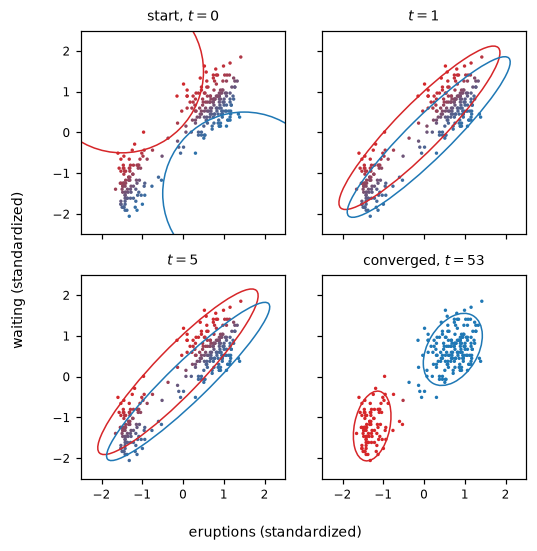

In [7]:
RED, BLUE = np.array([0.84, 0.15, 0.16]), np.array([0.12, 0.47, 0.71])

def draw_state(ax, state, title):
    """Points coloured by responsibility (red, blue, purple when shared) and the 2-sigma ellipse of each component."""
    pi_s, mu_s, sigma_s, resp_s = state
    ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=np.clip(resp_s[:, :1].numpy() * RED + resp_s[:, 1:].numpy() * BLUE, 0, 1), s=5, linewidths=0)
    for k, col in enumerate((RED, BLUE)):
        vals, vecs = torch.linalg.eigh(sigma_s[k])                       # ascending eigenvalues
        angle = math.degrees(math.atan2(vecs[1, 1].item(), vecs[0, 1].item()))
        ax.add_patch(Ellipse(mu_s[k].numpy(), 4 * math.sqrt(vals[1].item()), 4 * math.sqrt(vals[0].item()), angle=angle, fill=False, color=col, lw=1.0))
    ax.set(title=title, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect="equal")

fig, axes = plt.subplots(2, 2, figsize=(COL_W, COL_W), sharex=True, sharey=True)
for ax, t, title in zip(axes.flat, (0, 1, 5, -1), ("start, $t=0$", "$t=1$", "$t=5$", f"converged, $t={fit['n_iter']}$")):
    draw_state(ax, fit["history"][t], title)
fig.supxlabel("eruptions (standardized)", fontsize=9)
fig.supylabel("waiting (standardized)", fontsize=9)
fig.tight_layout()
save_figure(fig, "em_iterations.pdf")
plt.show()

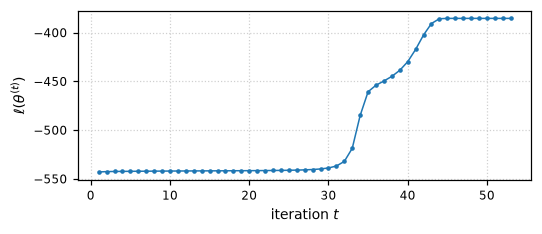

In [8]:
fig, ax = plt.subplots(figsize=(COL_W, 2.2))
ax.plot(np.arange(1, len(ll)), ll[1:], "o-", ms=2, lw=1)
ax.set(xlabel="iteration $t$", ylabel=r"$\ell(\theta^{(t)})$")
ax.grid(True, ls=":", alpha=0.6)
fig.tight_layout()
save_figure(fig, "em_loglik.pdf")
plt.show()

**Fixed point.** 200 further iterations bring the parameters to the fixed point of the EM map in double precision. There one more EM step leaves them unchanged to $10^{-8}$, and the gradient of $\ell$ with respect to the means, computed by `torch.autograd`, vanishes: fixed points of EM are stationary points of $\ell$ (Remark 3.2 of the paper).

In [9]:
polished = run_em(X, pi, mu, sigma, tol=0, max_iter=200)       # 200 further iterations: the parameters stop changing
pi_f, mu_f, sigma_f = polished["pi"], polished["mu"], polished["sigma"]
pi_n, mu_n, sigma_n = m_step(X, e_step(X, pi_f, mu_f, sigma_f)[0])
step_change = max((pi_n - pi_f).abs().max(), (mu_n - mu_f).abs().max(), (sigma_n - sigma_f).abs().max()).item()
mu_ad = mu_f.clone().requires_grad_(True)
(grad_mu,) = torch.autograd.grad(e_step(X, pi_f, mu_ad, sigma_f)[1], mu_ad)
grad_max = grad_mu.abs().max().item()
print(f"one more EM step changes the parameters by at most {step_change:.1e}; largest |dl/dmu| = {grad_max:.1e}")
check(step_change < 1e-8, "one more EM step at the fixed point changes the parameters by less than 1e-8")
check(grad_max <= 1e-6, "the gradient of l with respect to the means vanishes at the fixed point (autograd, at most 1e-6)")
RESULTS["fixed_point"] = {"further_iterations": 200, "max_parameter_change_one_more_step": step_change,
                          "max_abs_gradient_wrt_means": grad_max, "loglik": polished["logliks"][-1]}

one more EM step changes the parameters by at most 0.0e+00; largest |dl/dmu| = 5.6e-13
check: one more EM step at the fixed point changes the parameters by less than 1e-8 ✓
check: the gradient of l with respect to the means vanishes at the fixed point (autograd, at most 1e-6) ✓


**scikit-learn.** `GaussianMixture` with the same start, `tol=1e-10`, `reg_covar=0` and full covariances runs the same iteration under its own stopping rule, which tests the change of the mean log-likelihood per point.

In [10]:
gm = GaussianMixture(n_components=2, covariance_type="full", tol=1e-10, reg_covar=0.0, max_iter=1000,
                     weights_init=INIT[0].numpy(), means_init=INIT[1].numpy(),
                     precisions_init=np.linalg.inv(INIT[2].numpy()), random_state=0).fit(X.numpy())
sk_loglik = float(gm.score(X.numpy())) * X.shape[0]
sk_diff = abs(sk_loglik - ll[-1])
print(f"scikit-learn {sklearn.__version__}: {gm.n_iter_} iterations, l = {sk_loglik:.6f}, |difference| = {sk_diff:.1e}")
check(bool(gm.converged_) and sk_diff <= 1e-8, "scikit-learn from the same start reaches the same log-likelihood (difference at most 1e-8)")
RESULTS["sklearn"] = {"version": sklearn.__version__, "n_iter": int(gm.n_iter_), "converged": bool(gm.converged_), "tol": 1e-10,
                      "reg_covar": 0.0, "loglik": sk_loglik, "abs_difference": float(sk_diff)}

scikit-learn 1.9.1: 52 iterations, l = -385.460696, |difference| = 2.2e-11
check: scikit-learn from the same start reaches the same log-likelihood (difference at most 1e-8) ✓


**Random starts.** 20 starts with $K=2$: means at two random data points, identity covariances, equal weights.

In [11]:
def random_start(seed, k=2):
    """Means at k random data points, identity covariances, equal weights."""
    gen = torch.Generator().manual_seed(seed)
    return torch.full((k,), 1.0 / k), X[torch.randperm(X.shape[0], generator=gen)[:k]].clone(), torch.eye(2).repeat(k, 1, 1)

starts = [run_em(X, *random_start(seed)) for seed in range(20)]
finals = [r["logliks"][-1] for r in starts]
limits = sorted({round(v, 4) for v in finals}, reverse=True)
print(f"20 random starts, K = 2: {len(limits)} distinct limit(s) {limits}; {min(r['n_iter'] for r in starts)} to {max(r['n_iter'] for r in starts)} iterations")
check(min(np.diff(r["logliks"]).min() for r in starts) >= -1e-12, "the log-likelihood never decreases in any of the 20 random starts")
check(abs(max(finals) - ll[-1]) < 1e-6, "the best random start reaches the log-likelihood of the fit from INIT")
RESULTS["random_starts"] = {"n_starts": 20, "K": 2, "distinct_limits_4dp": limits, "best_loglik": max(finals),
                            "n_iter_min": min(r["n_iter"] for r in starts), "n_iter_max": max(r["n_iter"] for r in starts)}

20 random starts, K = 2: 1 distinct limit(s) [-385.4607]; 10 to 31 iterations
check: the log-likelihood never decreases in any of the 20 random starts ✓
check: the best random start reaches the log-likelihood of the fit from INIT ✓


In [12]:
RESULTS["runtime_seconds"] = round(time.perf_counter() - T_START, 2)
RESULTS["versions"] = {"python": platform.python_version(), "torch": torch.__version__, "numpy": np.__version__, "scikit_learn": sklearn.__version__}
# every number quoted in the paper, the README and the Conclusion below, with the rounding used there
QUOTED = {"n": 272, "means_raw_6": [3.487783, 70.897059], "hand_4": HAND.tolist(), "fit_iters": 53, "fit_ll_4": -385.4607, "ll0_2": -1331.48, "ll1_2": -542.98, "t_half": 35,
          "weights_3": [0.356, 0.644], "erupt_2": [2.04, 4.29], "wait_1": [54.5, 80.0], "cov_3": [[0.069, 0.435, 33.697], [0.170, 0.941, 36.046]],
          "step_change_1sig": 0.0, "grad_1sig": 5.6e-13, "sk_iters": 52, "sk_diff_1sig": 2.2e-11, "starts_limits": 1, "starts_best_4": -385.4607,
          "starts_iters": [10, 31], "n_checks": 13}
F, R, sig1 = RESULTS["fit"], RESULTS["random_starts"], lambda v: float(f"{v:.1e}")
computed = {"n": RESULTS["data"]["n"], "means_raw_6": [round(m, 6) for m in RESULTS["data"]["means_raw"]], "hand_4": [round(v, 4) for v in hand_values.tolist()],
            "fit_iters": F["n_iter"], "fit_ll_4": round(F["loglik"], 4),
            "ll0_2": round(F["loglik_t0"], 2), "ll1_2": round(F["loglik_t1"], 2), "t_half": F["t_half_remaining_gain"],
            "weights_3": [round(w, 3) for w in F["weights"]], "erupt_2": [round(m[0], 2) for m in F["means_min"]],
            "wait_1": [round(m[1], 1) for m in F["means_min"]], "cov_3": [[round(c[0][0], 3), round(c[0][1], 3), round(c[1][1], 3)] for c in F["covariances_min2"]],
            "step_change_1sig": sig1(RESULTS["fixed_point"]["max_parameter_change_one_more_step"]), "grad_1sig": sig1(RESULTS["fixed_point"]["max_abs_gradient_wrt_means"]),
            "sk_iters": RESULTS["sklearn"]["n_iter"], "sk_diff_1sig": sig1(RESULTS["sklearn"]["abs_difference"]), "starts_limits": len(R["distinct_limits_4dp"]),
            "starts_best_4": round(R["best_loglik"], 4), "starts_iters": [R["n_iter_min"], R["n_iter_max"]], "n_checks": len(CHECKS) + 1}  # + 1: the check below
check(computed == QUOTED, f"all {len(QUOTED)} numbers quoted in the paper and the README match this run")
RESULTS["n_checks"] = len(CHECKS)
Path("results.json").write_text(json.dumps(RESULTS, indent=2) + "\n")
print(f"results.json written: {RESULTS['n_checks']} checks passed, {len(RESULTS['figures'])} figures, {RESULTS['runtime_seconds']} s")

check: all 20 numbers quoted in the paper and the README match this run ✓
results.json written: 13 checks passed, 2 figures, 1.01 s


## 7. Conclusion
- **One iteration by hand.** On $x=(1,2,6,7)$ the computed responsibilities, weights, means and variances agree with the paper's table to $10^{-4}$; the step raises the log-likelihood from $-11.3689$ to $-6.3155$.
- **Old Faithful.** From the poor start, EM converges in 53 iterations to $\ell=-385.4607$. The first iteration raises $\ell$ from $-1331.48$ to $-542.98$; the log-likelihood then stays almost flat and covers half of the remaining gain only at iteration 35. The fit separates short eruptions (2.04 min, next wait 54.5 min, weight 0.356) from long ones (4.29 min, wait 80.0 min, weight 0.644).
- **Checks of the theory.** The log-likelihood never decreased; the weights summed to one and the covariances stayed symmetric positive definite after every M-step; the M-step output beat 20 random perturbations in $Q$; at the fixed point one more EM step changed no parameter at all (largest change $0$ in double precision) and the largest gradient entry with respect to the means was $5.6 \cdot 10^{-13}$.
- **scikit-learn and random starts.** scikit-learn 1.9.1 stops after 52 iterations and its log-likelihood differs from ours by $2.2 \cdot 10^{-11}$. All 20 random starts (10 to 31 iterations each) reach the same limit, $\ell=-385.4607$.